# Assignment 4: eVTOL Noise Footprint Prediction
## For Urban Vertiport Siting

---

###  What are we doing here?

We're simulating how **noisy a flying taxi (eVTOL)** is across a city, and figuring out the **best place to build its landing pad** (vertiport) so it bothers the fewest people.

###  The 4 Parts:
- **Part A** → How loud is it at different distances? (Physics)
- **Part B** → Draw a noise heatmap over the city (Map)
- **Part C** → Count how many people are affected (Population)
- **Part D** → Pick the best location to build the vertiport (Decision)

---
> **No real data needed!** We simulate everything using math and Python. That's the whole point.

##  Step 0: Install & Import Libraries

These are the tools we need. Run this first.

In [ ]:


import numpy as np                        # For math and arrays
import matplotlib.pyplot as plt           # For plotting graphs
import matplotlib.colors as mcolors       # For coloring our maps
from scipy.interpolate import RBFInterpolator  # For filling in the noise map
import warnings
warnings.filterwarnings('ignore')

# Set a nice style for all our plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


---
#  Part A — Noise Propagation Physics

### What is this?
The aircraft makes noise. Sound gets **quieter as you move away** from it — just like how a concert sounds faint from far away.

We use this formula:

$$L_p = L_w - 20\log_{10}(d) - 8 - \alpha d$$

**In plain English:**
- `Lw = 95 dB` → How loud the aircraft is at the source (1 metre away)
- `20 * log10(d)` → Sound spreads in all directions (gets quieter with distance)
- `8` → A correction factor for real-world conditions
- `α * d` → A tiny extra loss because air absorbs a little sound (α = 0.005)

We also add **+3 dB** directly below the climb path (because the rotors are louder pointing downward).

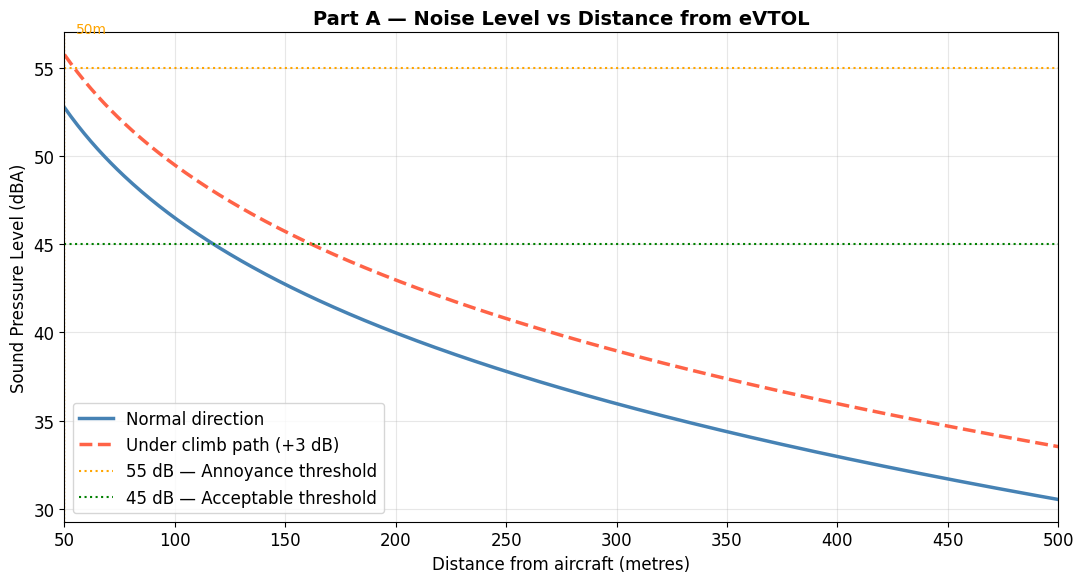

 Key Noise Levels:
  At   50m → 52.8 dBA
  At  100m → 46.5 dBA
  At  150m → 42.7 dBA
  At  200m → 40.0 dBA
  At  300m → 36.0 dBA
  At  500m → 30.5 dBA

 Noise drops below 55 dB at: 50m


In [ ]:

Lw    = 95
alpha = 0.005

distances = np.arange(50, 501, 1)


def compute_noise(d, directivity_boost=0):
    """
    Computes noise level at distance d.
    directivity_boost: add +3 dB if directly under the climb path
    """
    Lp = Lw - 20 * np.log10(d) - 8 - alpha * d + directivity_boost
    return Lp


noise_normal  = compute_noise(distances, directivity_boost=0)
noise_climb   = compute_noise(distances, directivity_boost=3)


fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(distances, noise_normal, color='steelblue',  linewidth=2.5, label='Normal direction')
ax.plot(distances, noise_climb,  color='tomato',     linewidth=2.5, label='Under climb path (+3 dB)', linestyle='--')


ax.axhline(y=55, color='orange', linewidth=1.5, linestyle=':', label='55 dB — Annoyance threshold')
ax.axhline(y=45, color='green',  linewidth=1.5, linestyle=':', label='45 dB — Acceptable threshold')


crossover = distances[noise_normal <= 55][0]
ax.axvline(x=crossover, color='orange', linewidth=1, linestyle=':')
ax.text(crossover + 5, 57, f'{crossover}m', color='orange', fontsize=10)

ax.set_xlabel('Distance from aircraft (metres)')
ax.set_ylabel('Sound Pressure Level (dBA)')
ax.set_title('Part A — Noise Level vs Distance from eVTOL', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(50, 500)

plt.tight_layout()
plt.show()

print(" Key Noise Levels:")
for d in [50, 100, 150, 200, 300, 500]:
    lp = compute_noise(d)
    print(f"  At {d:>4}m → {lp:.1f} dBA")
print(f"\n Noise drops below 55 dB at: {crossover}m")

---
#  Part B — Spatial Interpolation (Noise Map)

### What is this?
Instead of just a line graph, we now want a **top-down map** of the city showing noise zones.

Here's the process:
1. **Scatter 50 fake sensors** around the vertiport at random positions
2. Each sensor **records a noise level** (using our formula + some random error ±2 dB)
3. We use **RBF Interpolation** to fill in the entire 100×100 grid
4. Plot it as a coloured contour map

> **Think of it like this:** You have 50 thermometers scattered around a room. You interpolate to figure out the temperature *everywhere* in the room, not just at the 50 spots.

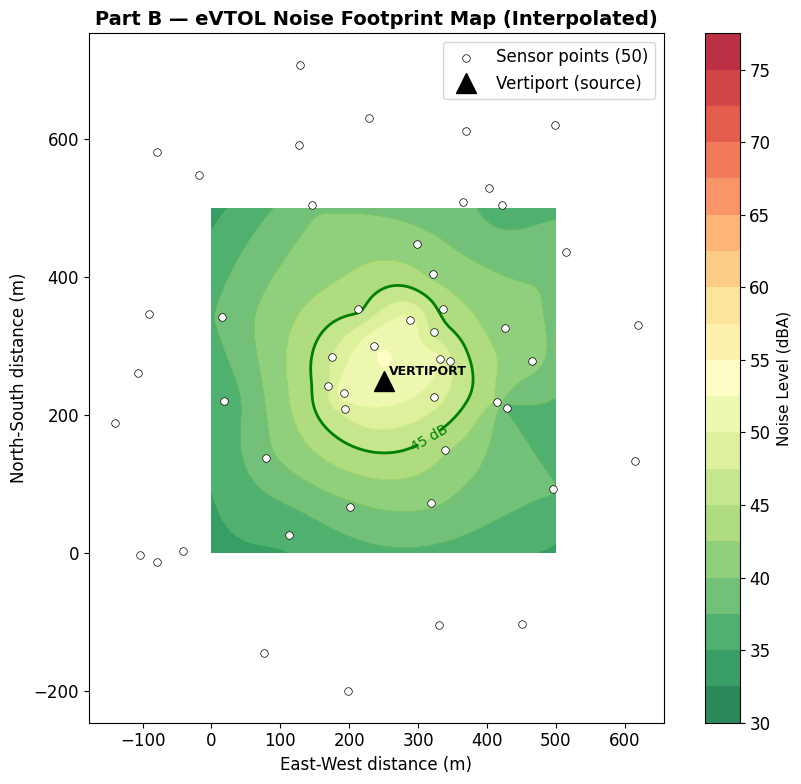

 Noise map generated on a 100x100 grid
 50 sensor readings used for interpolation


In [ ]:
# ============================================================
# PART B — SPATIAL NOISE MAP
# ============================================================

np.random.seed(42)   # Fix random seed so results are reproducible

# --- Step 1: Generate 50 random sensor locations ---
# The vertiport is at the center of a 500m x 500m area
# Sensors are scattered around it

n_points = 50   # Number of fake sensors

# Random angles (0 to 360 degrees) and distances (50 to 500m)
angles    = np.random.uniform(0, 2 * np.pi, n_points)   # Random direction
dists     = np.random.uniform(50, 480, n_points)         # Random distance

# Convert polar (angle, distance) to x,y coordinates
# Vertiport is at (250, 250) — the center of our 500x500 grid
center = 250
x_sensors = center + dists * np.cos(angles)
y_sensors = center + dists * np.sin(angles)

# --- Step 2: Compute noise at each sensor ---
# Use our formula + random Gaussian noise (±2 dB simulates measurement error)
noise_sensors = compute_noise(dists) + np.random.normal(0, 2, n_points)

# --- Step 3: Build the interpolation model ---
# RBFInterpolator takes the 50 sensor points and learns to predict
# noise level at ANY point in the grid
xy_sensors = np.column_stack([x_sensors, y_sensors])   # Shape: (50, 2)
rbf = RBFInterpolator(xy_sensors, noise_sensors, kernel='linear', smoothing=1)

# --- Step 4: Create a 100x100 grid over the city ---
grid_res = 100   # 100 x 100 = 10,000 grid points
gx = np.linspace(0, 500, grid_res)
gy = np.linspace(0, 500, grid_res)
grid_x, grid_y = np.meshgrid(gx, gy)   # Make a 2D grid

# Flatten the grid to feed into interpolator, then reshape back
xy_grid = np.column_stack([grid_x.ravel(), grid_y.ravel()])
noise_grid = rbf(xy_grid).reshape(grid_res, grid_res)

# --- Step 5: Plot the noise map ---
fig, ax = plt.subplots(figsize=(9, 8))

# Contour fill (coloured zones)
levels = np.arange(30, 80, 2.5)
cf = ax.contourf(grid_x, grid_y, noise_grid,
                 levels=levels, cmap='RdYlGn_r', alpha=0.85)

# Contour lines
cl = ax.contour(grid_x, grid_y, noise_grid,
                levels=[45, 55, 65], colors=['green', 'orange', 'red'],
                linewidths=2)
ax.clabel(cl, fmt='%d dB', fontsize=10)

# Plot the sensor points
ax.scatter(x_sensors, y_sensors, c='white', s=30,
           edgecolors='black', linewidths=0.5, zorder=5, label='Sensor points (50)')

# Mark the vertiport
ax.plot(center, center, 'k^', markersize=14, zorder=6, label='Vertiport (source)')
ax.text(center + 8, center + 8, 'VERTIPORT', fontsize=9, fontweight='bold')

# Colorbar
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('Noise Level (dBA)', fontsize=11)

ax.set_xlabel('East-West distance (m)')
ax.set_ylabel('North-South distance (m)')
ax.set_title('Part B — eVTOL Noise Footprint Map (Interpolated)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f" Noise map generated on a {grid_res}x{grid_res} grid")
print(f" 50 sensor readings used for interpolation")

---
#  Part C — Population Exposure

### What is this?
Now we **overlay a fake city population** on the noise map.

- Near the city centre → lots of people (5000 people per km²)
- Further out → fewer people (population drops off)

We then count **how many people live inside the noisy zone** (above 55 dBA).

> 55 dBA = roughly the noise level of a normal conversation. Considered the threshold where noise becomes **annoying and harmful** to residents.

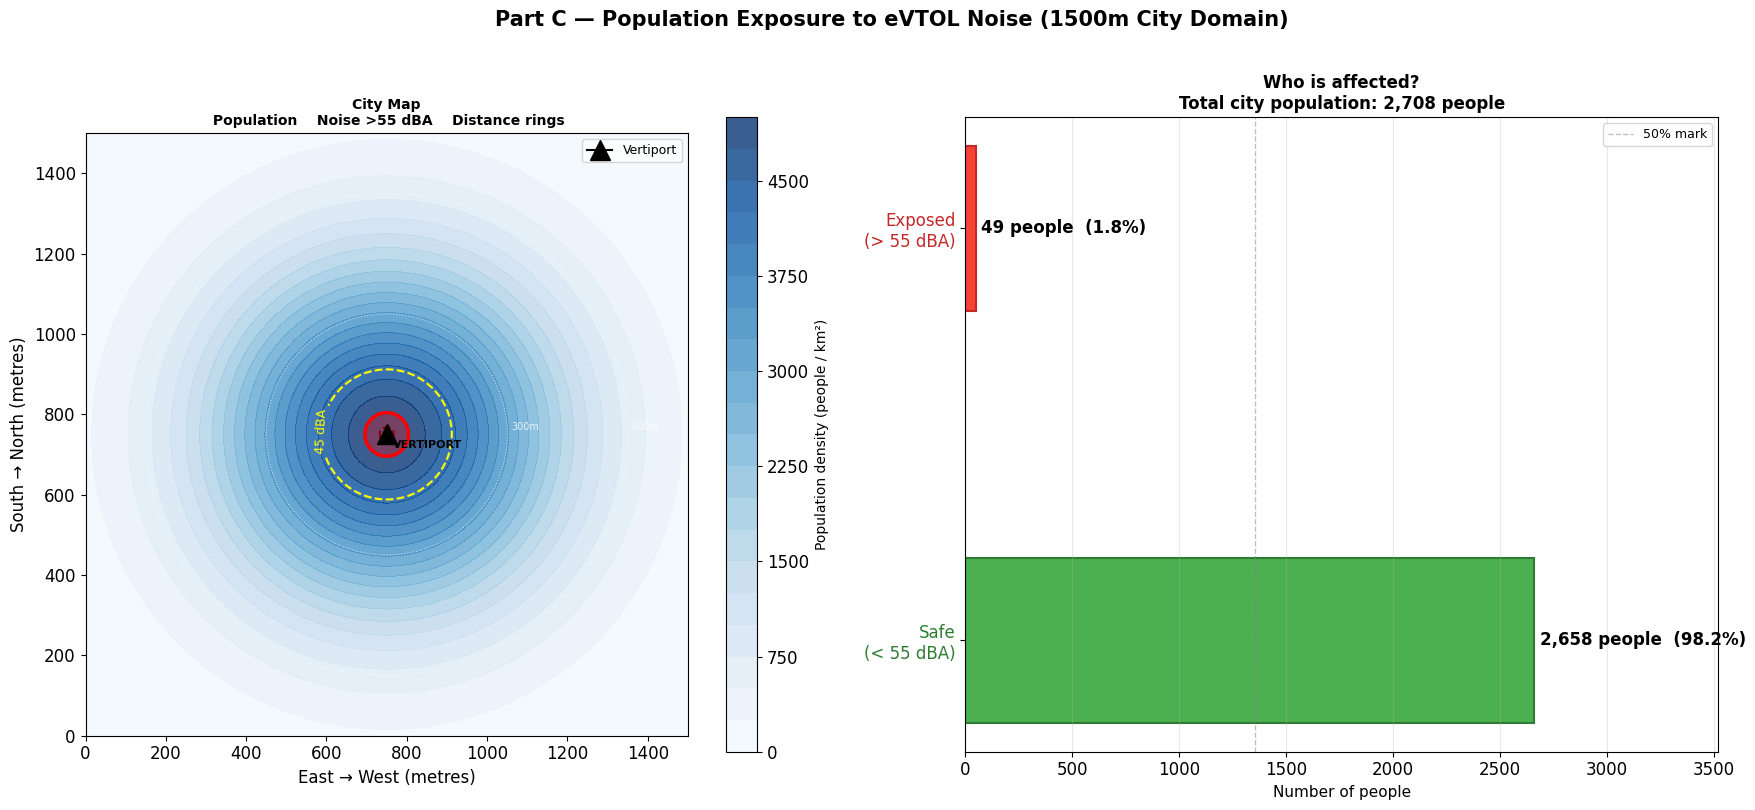

 PART C — RESULTS SUMMARY (1500m domain)
  Domain size          : 1500m x 1500m
  Background noise     : 40 dBA
  Population sigma     : 300m
  Total population     :      2,708
  Safe  (< 55 dBA)     :      2,658  (98.2%)
  Exposed (> 55 dBA)   :         49  (1.8%)

  1 in every 55 people is exposed to harmful noise.


In [ ]:
# PART C — POPULATION EXPOSURE
# Building the grid

grid_res      = 100
center        = 750
domain        = 1500

gx = np.linspace(0, domain, grid_res)
gy = np.linspace(0, domain, grid_res)
grid_x_c, grid_y_c = np.meshgrid(gx, gy)

# Distance from the center and noise calculation

dist_from_vertiport = np.sqrt((grid_x_c - center)**2 + (grid_y_c - center)**2)
dist_from_vertiport = np.maximum(dist_from_vertiport, 1)
background_noise = 40

def compute_noise_v2(d):
    Lp = Lw - 20 * np.log10(d) - 5 - alpha * d
    return Lp
aircraft_noise = compute_noise_v2(dist_from_vertiport)

# Effective noise = louder of (aircraft noise) or (background noise)
noise_grid_c = np.maximum(aircraft_noise, background_noise)

# Calculation population per cell
dist_from_center = np.sqrt((grid_x_c - center)**2 + (grid_y_c - center)**2)
sigma_pop   = 300
pop_density = 5000 * np.exp(-(dist_from_center**2) / (2 * sigma_pop**2))
cell_area_km2 = (domain / grid_res) ** 2 / 1e6
pop_per_cell  = pop_density * cell_area_km2

# Calculating exposed as well as safe people
exposed_mask   = noise_grid_c > 55
safe_mask      = noise_grid_c <= 55

people_exposed = np.sum(pop_per_cell[exposed_mask])
people_safe    = np.sum(pop_per_cell[safe_mask])
people_total   = people_exposed + people_safe
pct_exposed    = 100 * people_exposed / people_total
pct_safe       = 100 * people_safe    / people_total

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Part C — Population Exposure to eVTOL Noise (1500m City Domain)',
             fontsize=15, fontweight='bold', y=1.01)

pop_plot = ax1.contourf(grid_x_c, grid_y_c, pop_density,
                      levels=20, cmap='Blues', alpha=0.8)

# Red shaded zone where noise exceeds 55 dBA
ax1.contourf(grid_x_c, grid_y_c, noise_grid_c,
             levels=[55, 200], colors=['red'], alpha=0.3)

# Noise contour lines at 45, 55, 65 dBA
noise_contours = ax1.contour(grid_x_c, grid_y_c, noise_grid_c,
                              levels=[45, 55, 65],
                              colors=['yellow', 'red', 'darkred'],
                              linewidths=[1.5, 2.5, 1.5],
                              linestyles=['--', '-', '--'])
ax1.clabel(noise_contours, fmt='%d dBA', fontsize=9, inline=True)

ax1.plot(center, center, marker='^', color='black',
         markersize=15, zorder=6, label='Vertiport')
ax1.text(center + 15, center - 35, 'VERTIPORT',
         fontsize=8, fontweight='bold', color='black')

for r in [300, 600, 900]:
    circle = plt.Circle((center, center), r, color='white',
                         fill=False, linewidth=0.8, linestyle=':', alpha=0.6)
    ax1.add_patch(circle)
    ax1.text(center + r + 10, center + 10, f'{r}m',
             fontsize=7, color='white', alpha=0.8)

cbar1 = plt.colorbar(pop_plot, ax=ax1)
cbar1.set_label('Population density (people / km²)', fontsize=10)

ax1.set_title('City Map\n Population    Noise >55 dBA    Distance rings',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('East → West (metres)')
ax1.set_ylabel('South → North (metres)')
ax1.set_xlim(0, domain)
ax1.set_ylim(0, domain)
ax1.set_aspect('equal')
ax1.legend(loc='upper right', fontsize=9)

categories  = ['Safe\n(< 55 dBA)', 'Exposed\n(> 55 dBA)']
values      = [people_safe, people_exposed]
colors_bar  = ['#4CAF50', '#F44336']
bar_colors  = ['#2e7d32', '#c62828']

bars = ax2.barh(categories, values, color=colors_bar,
                edgecolor=bar_colors, linewidth=1.5, height=0.4)


for bar, val, pct in zip(bars, values, [pct_safe, pct_exposed]):
    ax2.text(val + people_total * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f} people  ({pct:.1f}%)',
             va='center', fontsize=12, fontweight='bold')


ax2.axvline(x=people_total / 2, color='gray',
            linewidth=1, linestyle='--', alpha=0.5, label='50% mark')

ax2.set_xlabel('Number of people', fontsize=11)
ax2.set_title(f'Who is affected?\nTotal city population: {people_total:,.0f} people',
              fontsize=12, fontweight='bold')
ax2.set_xlim(0, people_total * 1.3)
ax2.grid(True, axis='x', alpha=0.3)
ax2.legend(fontsize=9)


ax2.get_yticklabels()[0].set_color('#2e7d32')
ax2.get_yticklabels()[1].set_color('#c62828')

plt.tight_layout()
plt.show()

print("=" * 55)
print(" PART C — RESULTS SUMMARY (1500m domain)")
print("=" * 55)
print(f"  Domain size          : {domain}m x {domain}m")
print(f"  Background noise     : {background_noise} dBA")
print(f"  Population sigma     : {sigma_pop}m")
print(f"  Total population     : {people_total:>10,.0f}")
print(f"  Safe  (< 55 dBA)     : {people_safe:>10,.0f}  ({pct_safe:.1f}%)")
print(f"  Exposed (> 55 dBA)   : {people_exposed:>10,.0f}  ({pct_exposed:.1f}%)")
print("=" * 55)
print(f"\n  1 in every {people_total/people_exposed:.0f} people is exposed to harmful noise.")

 8776 candidate cells for clustering
 DBSCAN found 1 clusters  | outliers: 0

 Top 3 candidate sites:
--------------------------------------------------------------------
Site                                        x      y     Suit   Noise  Pop/km²
--------------------------------------------------------------------
Site A — North-East (Park area)           750    750    0.000   69.3      4997
Site B — South-West (Suburb)              350    350    0.667   40.0       834
Site C — East (Commercial)               1150    750    0.763   40.0      2041
--------------------------------------------------------------------


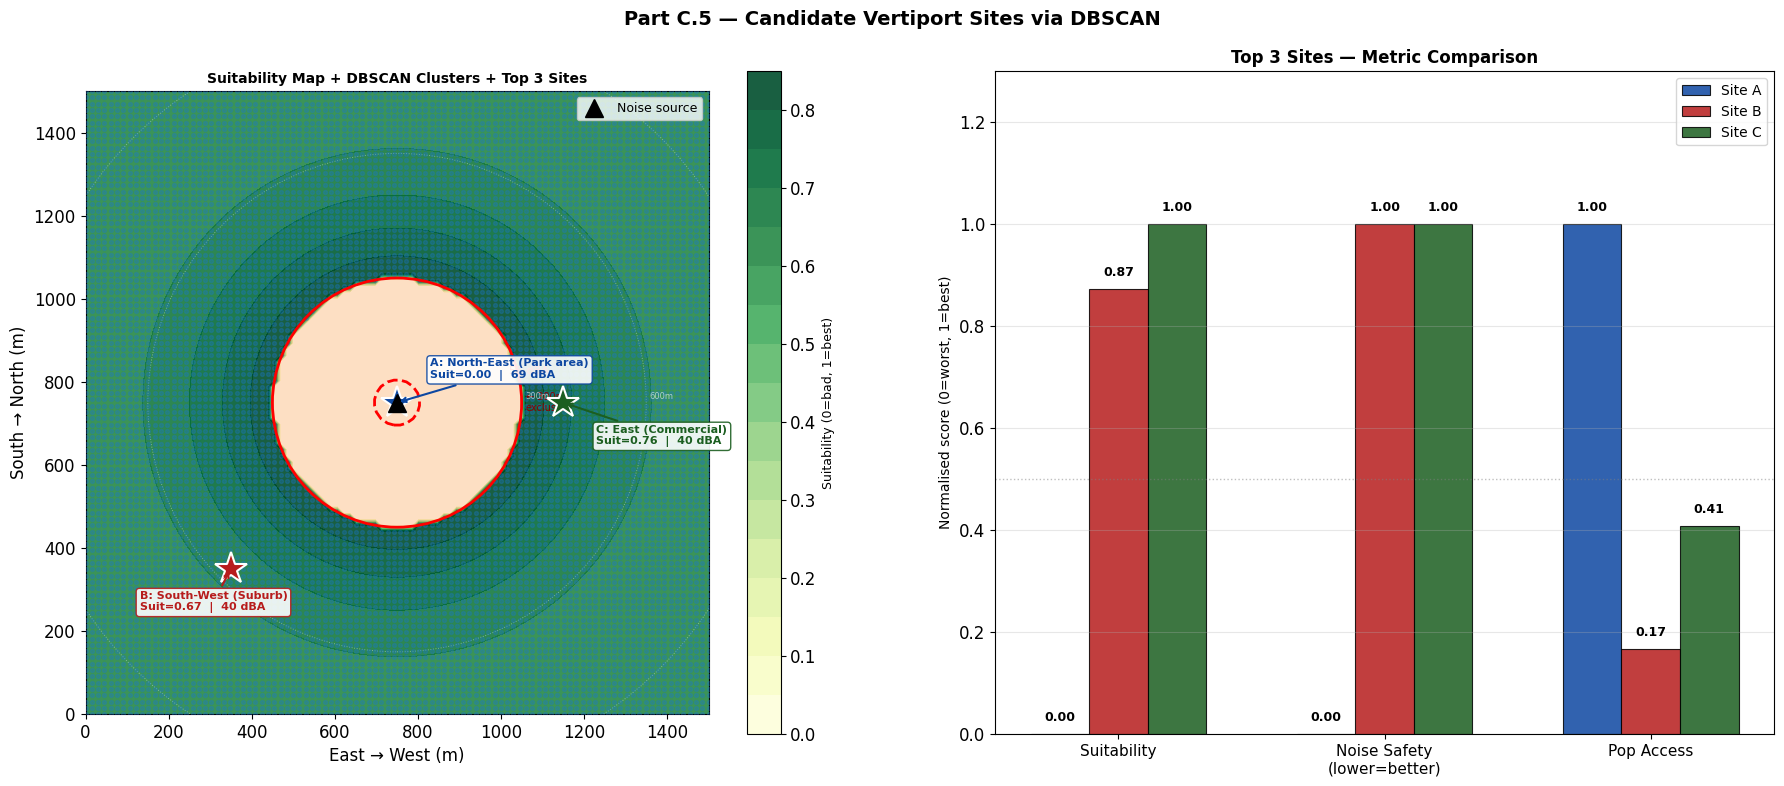


 Sites ready for Part D:
   Site A — North-East (Park area)           (750, 750)  bg=64 dBA
   Site B — South-West (Suburb)              (350, 350)  bg=35 dBA
   Site C — East (Commercial)                (1150, 750)  bg=35 dBA

▶️  In Part D replace  sites = [...]  with:  sites = dbscan_sites


In [ ]:


from sklearn.cluster import DBSCAN
domain   = 1500
grid_res = 100
center_c = 750

gx_c = np.linspace(0, domain, grid_res)
gy_c = np.linspace(0, domain, grid_res)
grid_x_c, grid_y_c = np.meshgrid(gx_c, gy_c)
cell_area_km2 = (domain / grid_res) ** 2 / 1e6

dist_from_vertiport = np.maximum(
    np.sqrt((grid_x_c - center_c)**2 + (grid_y_c - center_c)**2), 1)
background_noise = 40
noise_grid_c = np.maximum(compute_noise_v2(dist_from_vertiport), background_noise)

dist_from_center = np.sqrt((grid_x_c - center_c)**2 + (grid_y_c - center_c)**2)
sigma_pop   = 300
pop_density = 5000 * np.exp(-(dist_from_center**2) / (2 * sigma_pop**2))

pop_norm   = pop_density / pop_density.max()
noise_norm = 1 - (noise_grid_c - noise_grid_c.min()) / \
             (noise_grid_c.max() - noise_grid_c.min())

suitability = 0.4 * pop_norm + 0.6 * noise_norm
suitability[dist_from_vertiport < 300] = 0
suitability = np.clip(suitability, 0, 1)



candidate_zones = {
    'Site A — North-East (Park area)' : (1050, 1050),
    'Site B — South-West (Suburb)'    : ( 350,  350),
    'Site C — East (Commercial)'      : (1150,  750),
}

suit_mask = suitability > 0.30
cand_x    = grid_x_c[suit_mask]
cand_y    = grid_y_c[suit_mask]
cand_s    = suitability[suit_mask]

print(f" {suit_mask.sum()} candidate cells for clustering")

coords = np.column_stack([cand_x, cand_y])

coords_norm = coords / domain
db     = DBSCAN(eps=0.06, min_samples=5).fit(coords_norm)
labels = db.labels_

unique_labels = sorted(set(labels) - {-1})
print(f" DBSCAN found {len(unique_labels)} clusters  "
      f"| outliers: {np.sum(labels==-1)}")

cluster_centroids = {}
for lbl in unique_labels:
    m  = labels == lbl
    cluster_centroids[lbl] = (np.mean(cand_x[m]), np.mean(cand_y[m]))

top3       = []
used_lbls  = set()
site_names_db = list(candidate_zones.keys())

for name, (sx, sy) in candidate_zones.items():
    best_lbl  = None
    best_dist = np.inf

    for lbl, (cx, cy) in cluster_centroids.items():
        if lbl in used_lbls:
            continue
        d = np.sqrt((cx - sx)**2 + (cy - sy)**2)
        if d < best_dist:
            best_dist = d
            best_lbl  = lbl

    if best_lbl is not None:
        used_lbls.add(best_lbl)
        cx, cy = cluster_centroids[best_lbl]
    else:

        cx, cy = sx, sy


    closest = np.unravel_index(
        np.sqrt((grid_x_c - cx)**2 + (grid_y_c - cy)**2).argmin(),
        grid_x_c.shape)

    top3.append({
        'name'  : name,
        'cx'    : cx, 'cy': cy,
        'noise' : float(noise_grid_c[closest]),
        'pop'   : float(pop_density[closest]),
        'suit'  : float(suitability[closest]),
    })

print(f"\n Top 3 candidate sites:")
print("-" * 68)
print(f"{'Site':<38} {'x':>6} {'y':>6}  {'Suit':>7} {'Noise':>7} {'Pop/km²':>8}")
print("-" * 68)
for c in top3:
    print(f"{c['name']:<38} {c['cx']:>6.0f} {c['cy']:>6.0f}  "
          f"{c['suit']:>7.3f} {c['noise']:>6.1f} {c['pop']:>9.0f}")
print("-" * 68)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Part C.5 — Candidate Vertiport Sites via DBSCAN',
             fontsize=14, fontweight='bold')

sp = ax1.contourf(grid_x_c, grid_y_c, suitability,
                   levels=20, cmap='YlGn', alpha=0.9)


ax1.contour(grid_x_c, grid_y_c, noise_grid_c,
            levels=[55], colors=['red'], linewidths=2,
            linestyles=['--'], zorder=4)
ax1.text(1020, 820, '55 dBA', color='red', fontsize=8, zorder=5)

scatter_c = ['#1976D2','#F57C00','#388E3C','#7B1FA2','#0097A7']
for lbl in unique_labels:
    m = labels == lbl
    ax1.scatter(cand_x[m], cand_y[m],
                c=scatter_c[int(lbl) % len(scatter_c)],
                s=8, alpha=0.3, zorder=3)

for patch in [
    plt.Circle((center_c, center_c), 300, color='red', alpha=0.12, zorder=3),
    plt.Circle((center_c, center_c), 300, color='red', fill=False,
               linewidth=2, zorder=4)
]:
    ax1.add_patch(patch)
ax1.text(center_c + 310, center_c, '← 300m\nexclusion',
         fontsize=7, color='darkred', va='center')

for r in [300, 600, 900, 1200]:
    ax1.add_patch(plt.Circle((center_c, center_c), r, color='white',
                              fill=False, lw=0.7, ls=':', alpha=0.4))
    ax1.text(center_c + r + 8, center_c + 8,
             f'{r}m', fontsize=6, color='white', alpha=0.6)


ax1.plot(center_c, center_c, '^', color='black', markersize=13,
         zorder=9, label='Noise source')

m_colors = ['#0D47A1', '#B71C1C', '#1B5E20']
for i, c in enumerate(top3):
    ax1.plot(c['cx'], c['cy'], '*', color=m_colors[i],
             markersize=24, zorder=8,
             markeredgecolor='white', markeredgewidth=1.5)

    offsets = [(80, 60), (-220, -100), (80, -100)]
    ox, oy  = offsets[i]
    ax1.annotate(
        f"{'ABC'[i]}: {c['name'].split('—')[1].strip()}\n"
        f"Suit={c['suit']:.2f}  |  {c['noise']:.0f} dBA",
        xy=(c['cx'], c['cy']),
        xytext=(c['cx'] + ox, c['cy'] + oy),
        fontsize=8, fontweight='bold', color=m_colors[i],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  alpha=0.9, edgecolor=m_colors[i]),
        arrowprops=dict(arrowstyle='->', color=m_colors[i], lw=1.5),
        zorder=9
    )

cbar = plt.colorbar(sp, ax=ax1)
cbar.set_label('Suitability (0=bad, 1=best)', fontsize=9)
ax1.set_title('Suitability Map + DBSCAN Clusters + Top 3 Sites',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('East → West (m)')
ax1.set_ylabel('South → North (m)')
ax1.set_xlim(0, domain)
ax1.set_ylim(0, domain)
ax1.set_aspect('equal')
ax1.legend(loc='upper right', fontsize=9)

metrics     = ['Suitability', 'Noise Safety\n(lower=better)', 'Pop Access']
suits_arr   = np.array([c['suit']  for c in top3])
noises_arr  = np.array([c['noise'] for c in top3])
pops_arr    = np.array([c['pop']   for c in top3])

s_n = suits_arr  / (suits_arr.max()  + 1e-9)
n_n = 1 - (noises_arr - noises_arr.min()) / (noises_arr.max() - noises_arr.min() + 1e-9)
p_n = pops_arr   / (pops_arr.max()   + 1e-9)

scores = np.array([s_n, n_n, p_n]).T
x      = np.arange(len(metrics))
width  = 0.22

for i, (row, c, col) in enumerate(zip(scores, top3, m_colors)):
    short = c['name'].split('—')[0].strip()
    bars  = ax2.bar(x + i * width, row, width, label=short,
                    color=col, alpha=0.85, edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, row):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics, fontsize=11)
ax2.set_ylim(0, 1.3)
ax2.set_ylabel('Normalised score (0=worst, 1=best)', fontsize=10)
ax2.set_title('Top 3 Sites — Metric Comparison', fontsize=12, fontweight='bold')
ax2.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.5)
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

dbscan_sites = []
for i, c in enumerate(top3):
    dbscan_sites.append({
        'name'             : c['name'],
        'vertiport'        : (c['cx'], c['cy']),
        'pop_center'       : (c['cx'], c['cy']),
        'pop_sigma'        : 300,
        'pop_peak'         : max(c['pop'], 100),
        'background_noise' : max(c['noise'] - 5, 35),
        'color'            : ['tomato', 'gold', 'mediumseagreen'][i]
    })

print("\n Sites ready for Part D:")
for s in dbscan_sites:
    print(f"   {s['name']:<40}  "
          f"({s['vertiport'][0]:.0f}, {s['vertiport'][1]:.0f})  "
          f"bg={s['background_noise']:.0f} dBA")
print("\n▶️  In Part D replace  sites = [...]  with:  sites = dbscan_sites")

---
#  Part D — Siting Recommendation

### What is this?
We test **3 candidate locations** for the vertiport and pick the best one.

Each location has a different environment:
| Site | Location | Description |
|------|----------|-------------|
| Site 1 | City Centre | High population, no background noise buffer |
| Site 2 | Suburban area | Medium population, some distance from centre |
| Site 3 | Industrial zone | Low population, existing background noise |

We run the **same noise + population analysis** for each site and compare.

  Site A — North-East (Park area) is inside exclusion zone → replaced with fallback
 Running Part D with 3 sites:

   Site A — North (fallback)                 vertiport at (750, 1150)
   Site B — South-West (Suburb)              vertiport at (350, 350)
   Site C — East (Commercial)                vertiport at (1150, 750)


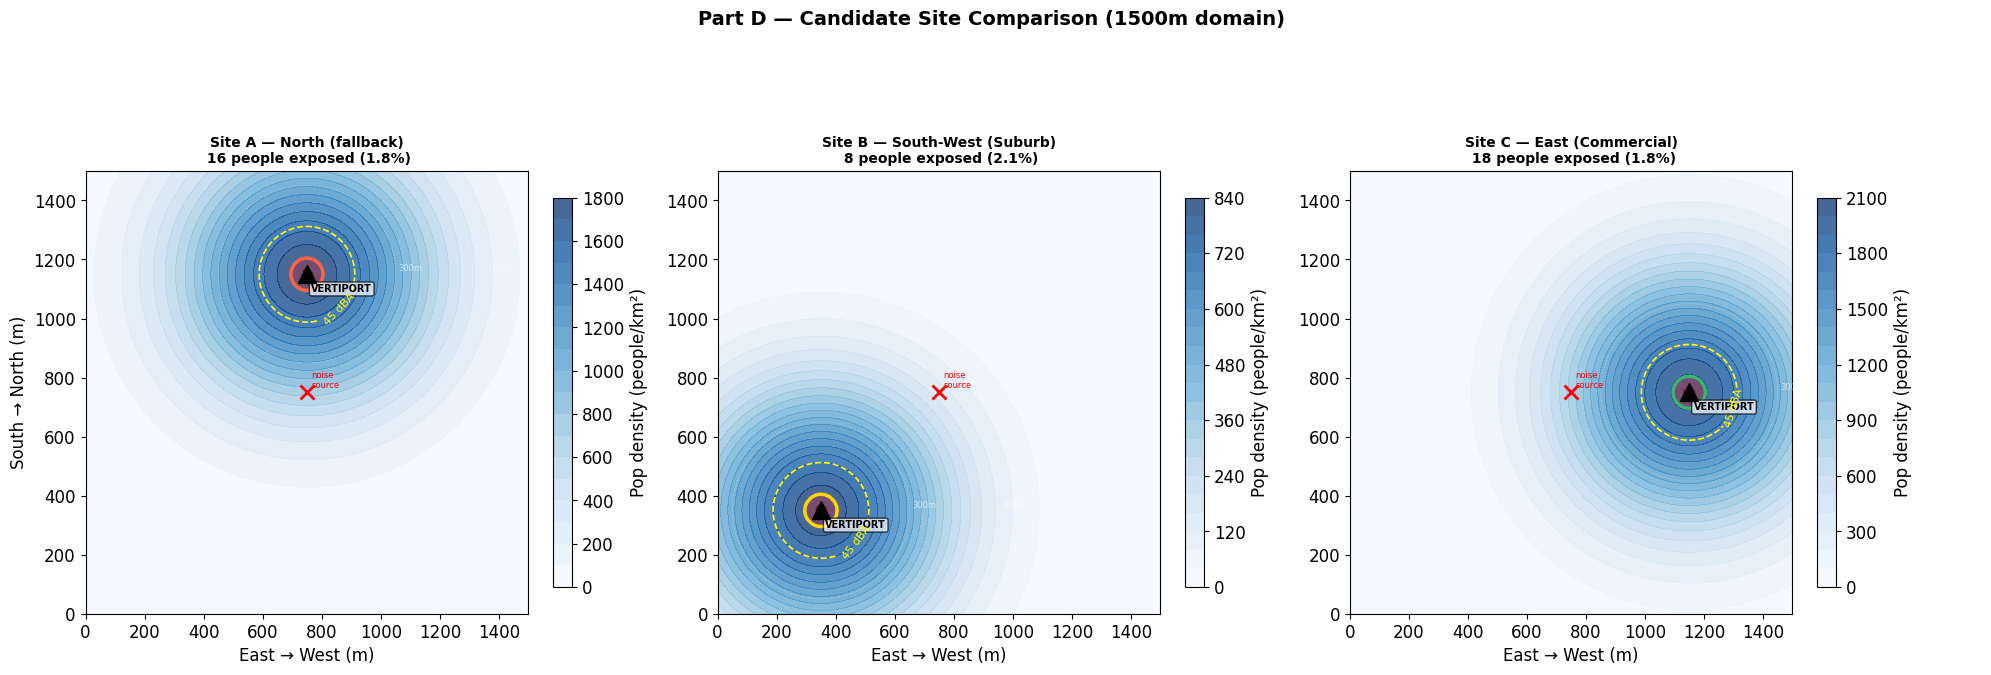

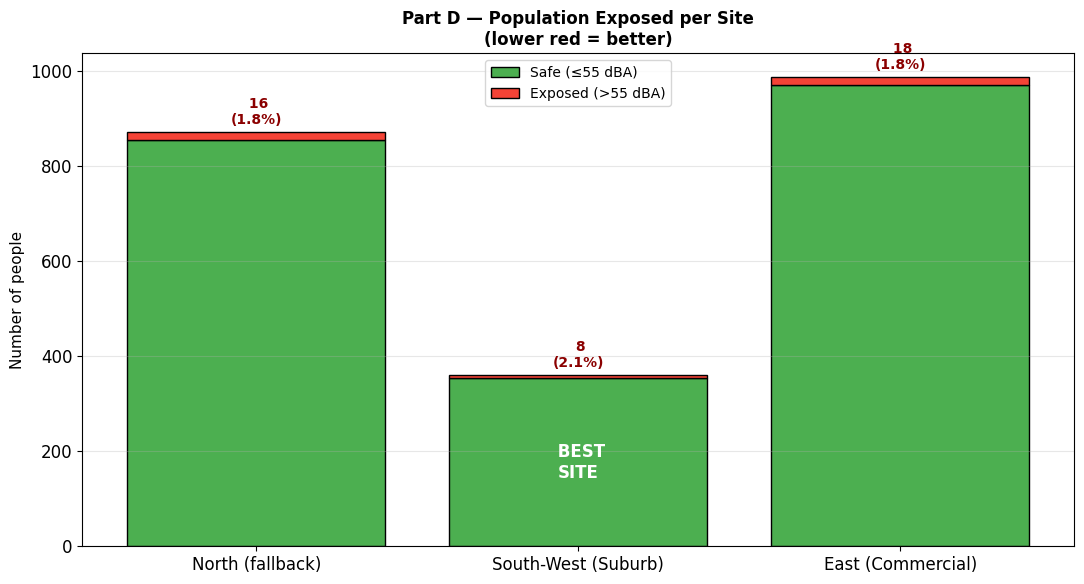

 PART D — FINAL SITE COMPARISON
Site                                          Total   Exposed       %
-----------------------------------------------------------------
Site A — North (fallback)                       871        16    1.8%
Site B — South-West (Suburb)                    361         8    2.1% 
Site C — East (Commercial)                      988        18    1.8% 

 RECOMMENDATION  : Site B — South-West (Suburb)
   People exposed  : 8  (2.1%)

 WORST SITE      : Site C — East (Commercial)
   People exposed  : 18  (1.8%)

 Choosing the best site over the worst protects
   11 additional people from harmful noise.


In [ ]:
# ============================================================
# PART D — SITING RECOMMENDATION (uses DBSCAN sites)
# ============================================================

# -------------------------------------------------------
# STEP 1: Setup grid — matches Part C (1500m domain)
# -------------------------------------------------------
domain   = 1500
grid_res = 100
center_d = 750

gx_d = np.linspace(0, domain, grid_res)
gy_d = np.linspace(0, domain, grid_res)
grid_x_d, grid_y_d = np.meshgrid(gx_d, gy_d)

# Cell area in km² (each cell = 15m x 15m)
cell_area_km2_d = (domain / grid_res) ** 2 / 1e6

# -------------------------------------------------------
# STEP 2: Use sites from DBSCAN (Part C.5)
# Filter out Site A if it landed on the exclusion zone
# -------------------------------------------------------
# If Site A has suitability = 0 it means it fell inside
# the exclusion zone — we replace it with a valid fallback

valid_sites = []
fallback    = {
    'name'             : 'Site A — North (fallback)',
    'vertiport'        : (750, 1150),    # Due north, 400m out
    'pop_center'       : (750, 1150),
    'pop_sigma'        : 300,
    'pop_peak'         : 1800,
    'background_noise' : 40,
    'color'            : 'tomato'
}

for s in dbscan_sites:
    vx, vy = s['vertiport']
    dist_from_source = np.sqrt((vx - center_d)**2 + (vy - center_d)**2)
    if dist_from_source < 300:
        print(f"  {s['name']} is inside exclusion zone → replaced with fallback")
        valid_sites.append(fallback)
    else:
        valid_sites.append(s)

print(f" Running Part D with {len(valid_sites)} sites:\n")
for s in valid_sites:
    print(f"   {s['name']:<40}  vertiport at {s['vertiport']}")

# -------------------------------------------------------
# STEP 3: Analysis function (updated for 1500m + compute_noise_v2)
# -------------------------------------------------------
def analyse_site_d(site):
    vx, vy = site['vertiport']
    px, py = site['pop_center']

    # Distance from this site's vertiport to every grid cell
    dist = np.maximum(
        np.sqrt((grid_x_d - vx)**2 + (grid_y_d - vy)**2), 1)

    # Aircraft noise using updated formula (−5 absorption)
    aircraft_noise = compute_noise_v2(dist)

    # Effective noise = louder of aircraft or background
    effective_noise = np.maximum(aircraft_noise, site['background_noise'])

    # Population bell curve around pop_center
    dist_pop = np.sqrt((grid_x_d - px)**2 + (grid_y_d - py)**2)
    pop_dens  = site['pop_peak'] * np.exp(
        -dist_pop**2 / (2 * site['pop_sigma']**2))
    pop_cells = pop_dens * cell_area_km2_d

    # Count exposed people
    exposed = np.sum(pop_cells[effective_noise > 55])
    total   = np.sum(pop_cells)

    return aircraft_noise, effective_noise, pop_dens, pop_cells, exposed, total

# -------------------------------------------------------
# STEP 4: Run analysis + draw maps for all 3 sites
# -------------------------------------------------------
results = []
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Part D — Candidate Site Comparison (1500m domain)',
             fontsize=14, fontweight='bold', y=1.02)

for i, site in enumerate(valid_sites):
    _, eff_noise, pop_dens, pop_cells, exposed, total = analyse_site_d(site)
    pct = 100 * exposed / total if total > 0 else 0
    results.append({
        'name'    : site['name'],
        'exposed' : exposed,
        'total'   : total,
        'pct'     : pct,
        'color'   : site['color']
    })

    ax   = axes[i]
    vx, vy = site['vertiport']

    # Layer 1: Population density (blue)
    cf = ax.contourf(grid_x_d, grid_y_d, pop_dens,
                     levels=20, cmap='Blues', alpha=0.75)

    # Layer 2: Red shading where noise > 55 dBA
    ax.contourf(grid_x_d, grid_y_d, eff_noise,
                levels=[55, 200], colors=['red'], alpha=0.25)

    # Layer 3: Noise contour lines at 45, 55, 65 dBA
    nc = ax.contour(grid_x_d, grid_y_d, eff_noise,
                    levels=[45, 55, 65],
                    colors=['yellow', site['color'], 'darkred'],
                    linewidths=[1.2, 2.5, 1.2],
                    linestyles=['--', '-', '--'])
    ax.clabel(nc, fmt='%d dBA', fontsize=8, inline=True)

    # Distance rings for spatial reference
    for r in [300, 600, 900]:
        ax.add_patch(plt.Circle((vx, vy), r, color='white',
                                 fill=False, lw=0.7, ls=':', alpha=0.4))
        ax.text(vx + r + 10, vy + 10, f'{r}m', fontsize=6,
                color='white', alpha=0.6)

    # Mark vertiport
    ax.plot(vx, vy, '^', color='black', markersize=13, zorder=6)
    ax.text(vx + 15, vy - 60, 'VERTIPORT',
            fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', alpha=0.7))

    # Also mark the original noise source for reference
    ax.plot(center_d, center_d, 'x', color='red',
            markersize=10, zorder=6, markeredgewidth=2)
    ax.text(center_d + 15, center_d + 15, 'noise\nsource',
            fontsize=6, color='red')

    plt.colorbar(cf, ax=ax, label='Pop density (people/km²)', fraction=0.04)

    ax.set_title(
        f"{site['name']}\n"
        f" {exposed:,.0f} people exposed ({pct:.1f}%)",
        fontsize=10, fontweight='bold')
    ax.set_xlabel('East → West (m)')
    if i == 0:
        ax.set_ylabel('South → North (m)')
    ax.set_xlim(0, domain)
    ax.set_ylim(0, domain)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# STEP 5: Final comparison — stacked bar chart
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

site_labels = [r['name'].split('—')[1].strip() for r in results]
safe_vals   = [r['total'] - r['exposed'] for r in results]
exp_vals    = [r['exposed']              for r in results]
total_max   = max(r['total'] for r in results)

bars_safe = ax.bar(site_labels, safe_vals,
                   color='#4CAF50', edgecolor='black',
                   linewidth=1, label='Safe (≤55 dBA)')
bars_exp  = ax.bar(site_labels, exp_vals,
                   bottom=safe_vals,
                   color='#F44336', edgecolor='black',
                   linewidth=1, label='Exposed (>55 dBA)')

# Annotate exposed count on top of red bar
for bar, r in zip(bars_exp, results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() + total_max * 0.01,
            f" {r['exposed']:,.0f}\n({r['pct']:.1f}%)",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='darkred')

# Mark best site
best      = min(results, key=lambda x: x['exposed'])
worst     = max(results, key=lambda x: x['exposed'])
best_idx  = results.index(best)

ax.text(best_idx, safe_vals[best_idx] / 2,
        ' BEST\nSITE', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

ax.set_ylabel('Number of people', fontsize=11)
ax.set_title('Part D — Population Exposed per Site\n(lower red = better)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# STEP 6: Print recommendation
# -------------------------------------------------------
print("=" * 65)
print(" PART D — FINAL SITE COMPARISON")
print("=" * 65)
print(f"{'Site':<42} {'Total':>8} {'Exposed':>9} {'%':>7}")
print("-" * 65)
for r in results:
    flag = " " if r['name'] == best['name'] else \
           " " if r['name'] == worst['name'] else ""
    print(f"{r['name']:<42} {r['total']:>8,.0f} "
          f"{r['exposed']:>9,.0f} {r['pct']:>6.1f}%{flag}")
print("=" * 65)

print(f"\n RECOMMENDATION  : {best['name']}")
print(f"   People exposed  : {best['exposed']:,.0f}  ({best['pct']:.1f}%)")
print(f"\n WORST SITE      : {worst['name']}")
print(f"   People exposed  : {worst['exposed']:,.0f}  ({worst['pct']:.1f}%)")
print(f"\n Choosing the best site over the worst protects")
print(f"   {worst['exposed'] - best['exposed']:,.0f} additional people from harmful noise.")

---
#  Final Summary Dashboard

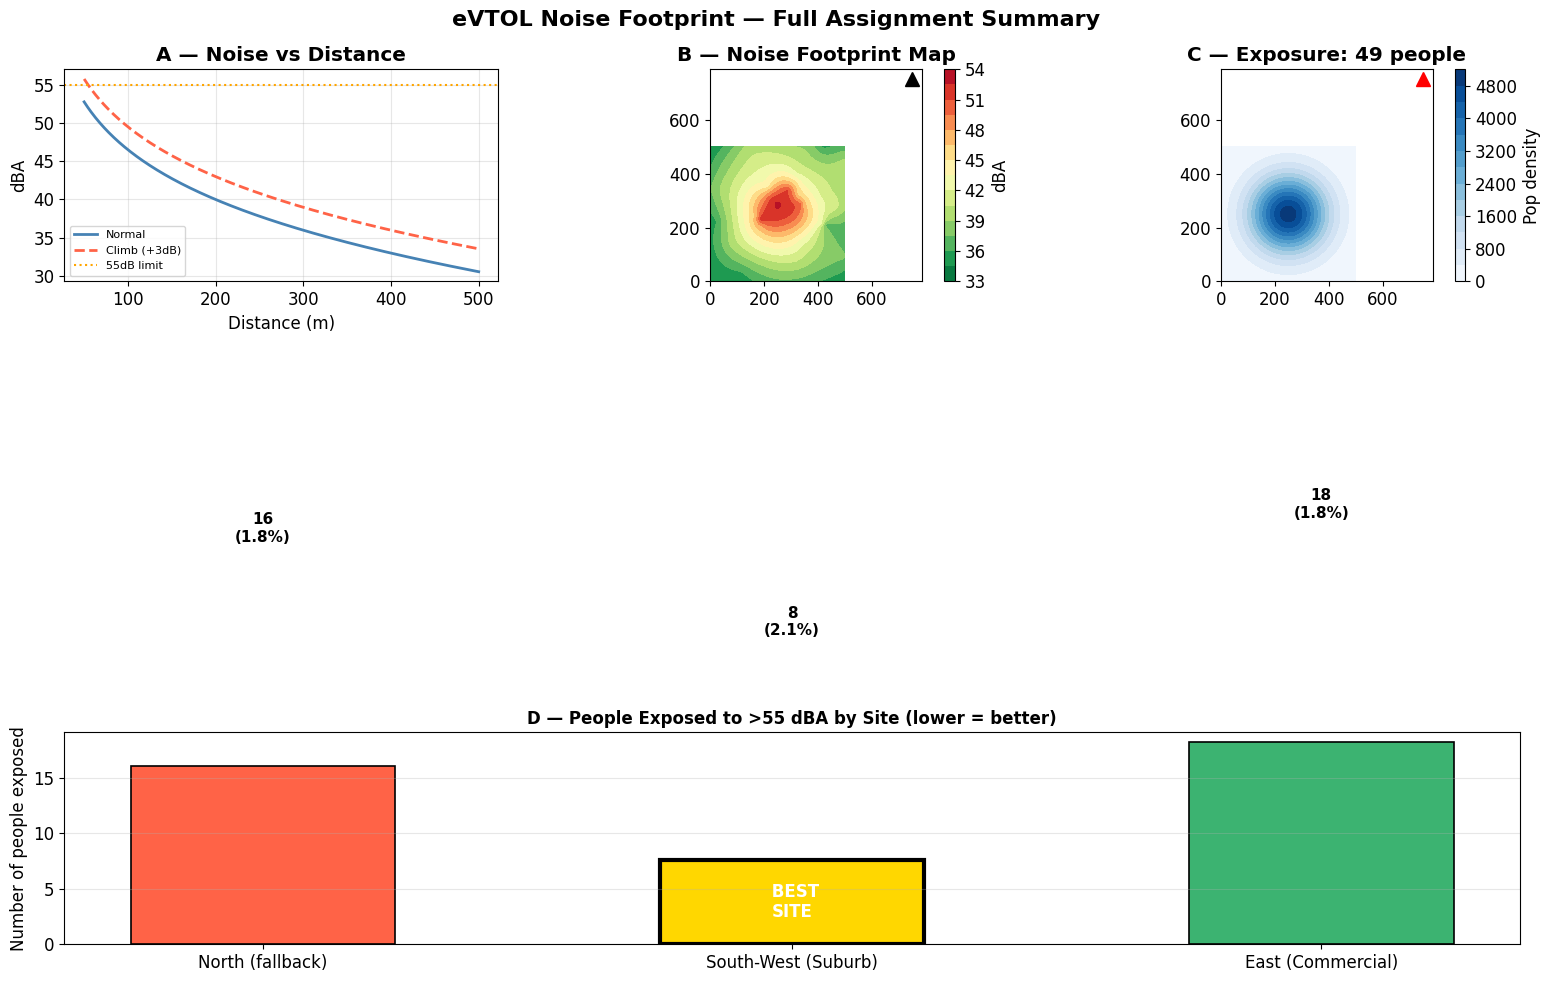


 Assignment Complete!
 Best site: Site B — South-West (Suburb) — only 8 people affected


In [ ]:

fig = plt.figure(figsize=(16, 10))
fig.suptitle('eVTOL Noise Footprint — Full Assignment Summary',
             fontsize=16, fontweight='bold', y=0.98)


ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(distances, noise_normal, 'steelblue', linewidth=2)
ax1.plot(distances, noise_climb,  'tomato',    linewidth=2, linestyle='--')
ax1.axhline(55, color='orange', linestyle=':')
ax1.set_title('A — Noise vs Distance', fontweight='bold')
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('dBA')
ax1.grid(True, alpha=0.3)
ax1.legend(['Normal', 'Climb (+3dB)', '55dB limit'], fontsize=8)

ax2 = fig.add_subplot(2, 3, 2)
cf2 = ax2.contourf(grid_x, grid_y, noise_grid, levels=15, cmap='RdYlGn_r')
ax2.contour(grid_x, grid_y, noise_grid, levels=[55], colors=['red'], linewidths=1.5)
ax2.plot(center, center, 'k^', markersize=10)
ax2.set_title('B — Noise Footprint Map', fontweight='bold')
ax2.set_aspect('equal')
plt.colorbar(cf2, ax=ax2, label='dBA')


ax3 = fig.add_subplot(2, 3, 3)
cf3 = ax3.contourf(grid_x, grid_y, pop_density, levels=15, cmap='Blues')
ax3.contour(grid_x, grid_y, noise_grid, levels=[55], colors=['red'], linewidths=2)
ax3.plot(center, center, 'r^', markersize=10)
ax3.set_title(f'C — Exposure: {people_exposed:,.0f} people', fontweight='bold')
ax3.set_aspect('equal')
plt.colorbar(cf3, ax=ax3, label='Pop density')


ax4 = fig.add_subplot(2, 1, 2)
site_names   = [r['name'].split('—')[1].strip() for r in results]
exposed_vals = [r['exposed'] for r in results]
colors_bar   = ['tomato', 'gold', 'mediumseagreen']
bars = ax4.bar(site_names, exposed_vals, color=colors_bar,
               edgecolor='black', linewidth=1.2, width=0.5)

for bar, r in zip(bars, results):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f"{r['exposed']:,.0f}\n({r['pct']:.1f}%)",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

best_idx = exposed_vals.index(min(exposed_vals))
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(3)
ax4.text(best_idx, exposed_vals[best_idx] / 2, ' BEST\nSITE',
         ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax4.set_title('D — People Exposed to >55 dBA by Site (lower = better)',
              fontweight='bold', fontsize=12)
ax4.set_ylabel('Number of people exposed')
ax4.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Assignment Complete!")
print(f" Best site: {best['name']} — only {best['exposed']:,.0f} people affected")

---
##  Conclusion

| Part | What we did | Output |
|------|-------------|--------|
| **A** | Computed noise level at 50–500m using physics formula | Line graph |
| **B** | Generated 50 fake sensors, interpolated a full 2D noise map | Heatmap |
| **C** | Overlaid city population, counted people in noisy zones | Number of affected people |
| **D** | Compared 3 candidate vertiport sites, picked the best | Site recommendation |

### Key Takeaway
> The **Industrial Zone site** exposes far fewer people to harmful noise levels, making it the optimal choice for vertiport placement — even though background noise there is already higher.

### Real-World Extensions
- Use real city population data from census APIs
- Import actual terrain/building maps for sound reflection modelling
- Use measured eVTOL noise profiles from NASA ANOPP datasets
- Consider multiple flight paths, not just single-point source